# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "so2f2"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[1.266 1.266 1.266 ... 1.472 1.472 1.472] [1.266 1.266 1.266 ... 1.472 1.472 1.472] [1.266 1.266 1.266 ... 1.472 1.472 1.472] [1.266 1.266 1.266 ... 1.472 1.472 1.472] [1.266 1.266 1.266 ... 1.472 1.472 1.472] [1.266 1.266 1.266 ... 1.472 1.472 1.472]] [[1.276 1.276 1.276 ... 1.472 1.472 1.472] [1.276 1.276 1.276 ... 1.472 1.472 1.472] [1.276 1.276 1.276 ... 1.472 1.472 1.472] [1.276 1.276 1.276 ... 1.472 1.472 1.472] [1.276 1.276 1.276 ... 1.472 1.472 1.472] [1.276 1.276 1.276 ... 1.472 1.472 1.472]] [[1.277 1.277 1.277 ... 1.497 1.497 1.497] [1.277 1.277 1.277 ... 1.497 1.497 1.497] [1.277 1.277 1.277 ... 1.497 1.497 1.497] [1.277 1.277 1.277 ... 1.497 1.497 1.497] [1.277 1.277 1.277 ... 1.497 1.497 1.497] [1.277 1.277 1.277 ... 1.497 1.497 1.497]] ... [[2.772 2.772 2.772 ... 3.043 3.04 3.037] [2.772 2.772 2.772 ... 3.0429999999999997 3.04 3.037] [2.772 2.772 2.772 ... 3.096 3.04 3.037] [2.772 2.772 2.772 ... 3.1146666666666665 3.075833333333333 3.037] [2.772 2.772 2.772 ... 3.0788333333333333 3.04 3.037] [2.772 2.772 2.772 ... 3.0429999999999997 3.04 3.037]] [[2.792 2.792 2.792 ... 3.1010000000000004 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.1010000000000004 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.129 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.138666666666667 3.1248333333333336 3.111] [2.792 2.792 2.792 ... 3.1198333333333337 3.106 3.111] [2.792 2.792 2.792 ... 3.101 3.1060000000000003 3.111]] [[2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.135 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.167333333333333 3.1651666666666665 3.163] [2.79 2.79 2.79 ... 3.148833333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[1.419 1.419 1.419 ... 1.573 1.573 1.573] [1.419 1.419 1.419 ... 1.573 1.573 1.573] [1.419 1.419 1.419 ... 1.573 1.573 1.573] [1.419 1.419 1.419 ... 1.573 1.573 1.573] [1.419 1.419 1.419 ... 1.573 1.573 1.573] [1.419 1.419 1.419 ... 1.573 1.573 1.573]] [[1.423 1.423 1.423 ... 1.562 1.562 1.562] [1.423 1.423 1.423 ... 1.562 1.562 1.562] [1.423 1.423 1.423 ... 1.562 1.562 1.562] [1.423 1.423 1.423 ... 1.562 1.562 1.562] [1.423 1.423 1.423 ... 1.562 1.562 1.562] [1.423 1.423 1.423 ... 1.562 1.562 1.562]] [[1.425 1.425 1.425 ... 1.576 1.576 1.576] [1.425 1.425 1.425 ... 1.576 1.576 1.576] [1.425 1.425 1.425 ... 1.576 1.576 1.576] [1.425 1.425 1.425 ... 1.576 1.576 1.576] [1.425 1.425 1.425 ... 1.576 1.576 1.576] [1.425 1.425 1.425 ... 1.576 1.576 1.576]] ... [[2.772 2.772 2.772 ... 3.043 3.04 3.037] [2.772 2.772 2.772 ... 3.0429999999999997 3.04 3.037] [2.772 2.772 2.772 ... 3.096 3.04 3.037] [2.772 2.772 2.772 ... 3.1146666666666665 3.075833333333333 3.037] [2.772 2.772 2.772 ... 3.0788333333333333 3.04 3.037] [2.772 2.772 2.772 ... 3.0429999999999997 3.04 3.037]] [[2.792 2.792 2.792 ... 3.1010000000000004 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.1010000000000004 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.129 3.1060000000000003 3.111] [2.792 2.792 2.792 ... 3.138666666666667 3.1248333333333336 3.111] [2.792 2.792 2.792 ... 3.1198333333333337 3.106 3.111] [2.792 2.792 2.792 ... 3.101 3.1060000000000003 3.111]] [[2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.135 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.167333333333333 3.1651666666666665 3.163] [2.79 2.79 2.79 ... 3.148833333333333 3.1466666666666665 3.163] [2.79 2.79 2.79 ... 3.130333333333333 3.1466666666666665 3.163]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'so2f2' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[1.419      1.423      1.425      ... 1.439      1.443
    1.449     ]
   [1.455      1.457      1.468      ... 1.494      1.51
    1.511     ]
   [1.511      1.526      1.554      ... 1.546      1.557
    1.564     ]
   ...
   [2.128      2.172      1.86733333 ... 2.293      2.3025
    2.255     ]
   [2.328      2.614      2.632      ... 2.682      2.689
    2.693     ]
   [2.699      2.711      2.729      ... 2.772      2.792
    2.79      ]]

  [[1.419      1.423      1.425      ... 1.439      1.443
    1.449     ]
   [1.455      1.457      1.468      ... 1.494      1.51
    1.511     ]
   [1.511      1.526      1.554      ... 1.546      1.557
    1.564     ]
...
   [2.61958333 2.58       2.61771667 ... 2.6735     2.72880556
    2.75933333]
   [2.796      2.91633333 2.94       ... 2.99866667 3.05533333
    3.055     ]
   [3.07333333 3.059      3.05333333 ... 3.04       3.106
    3.14666667]]

  [[1.573      1.562      1.576      ... 1.632      1.646
    1.644     ]
   [1.652      1.663      1.652      ... 1.691      1.696
    1.708     ]
   [1.7        1.699      1.698      ... 1.779      1.785
    1.802     ]
   ...
   [2.59633333 2.6385     2.6205     ... 2.711      2.72133333
    2.8585    ]
   [2.957      2.937      2.955      ... 3.         3.08
    3.064     ]
   [3.094      3.078      3.064      ... 3.037      3.111
    3.163     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.043 3.1010000000000004 3.130333333333333] [1.573 1.562 1.576 ... 3.04 3.1060000000000003 3.1466666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]] [[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.0429999999999997 3.1010000000000004 3.130333333333333] [1.573 1.562 1.576 ... 3.04 3.1060000000000003 3.1466666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]] [[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.096 3.129 3.135] [1.573 1.562 1.576 ... 3.04 3.1060000000000003 3.1466666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]] [[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.1146666666666665 3.138666666666667 3.167333333333333] [1.573 1.562 1.576 ... 3.075833333333333 3.1248333333333336 3.1651666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]] [[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.0788333333333333 3.1198333333333337 3.148833333333333] [1.573 1.562 1.576 ... 3.04 3.106 3.1466666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]] [[1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] [1.419 1.423 1.425 ... 2.772 2.792 2.79] ... [1.573 1.562 1.576 ... 3.0429999999999997 3.101 3.130333333333333] [1.573 1.562 1.576 ... 3.04 3.1060000000000003 3.1466666666666665] [1.573 1.562 1.576 ... 3.037 3.111 3.163]]]
Units,ppt


### Longitudinal-mean

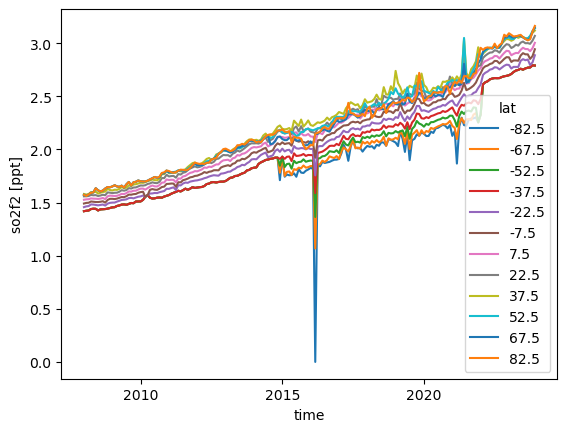

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

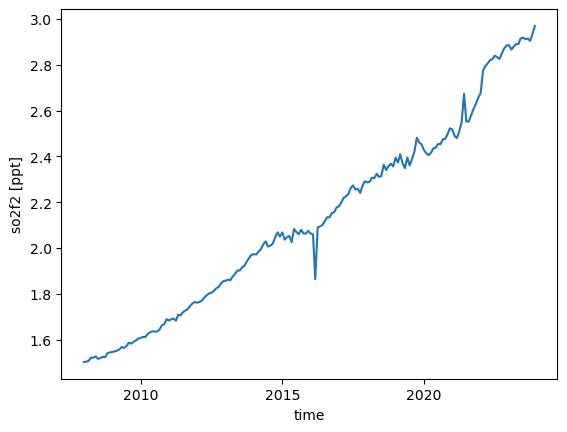

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

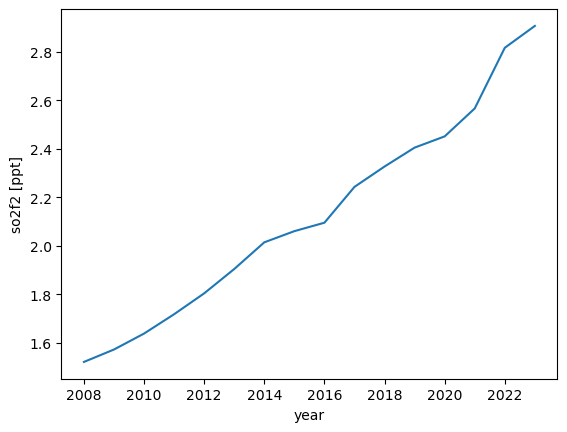

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4982 -0.481 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -0.2393 ... -8.528e-17

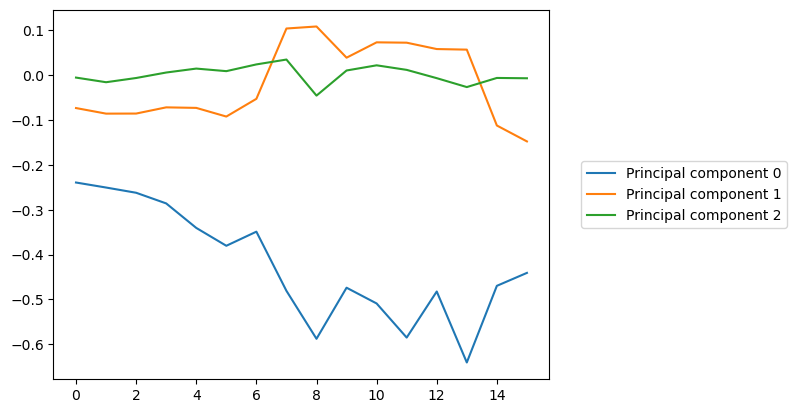

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

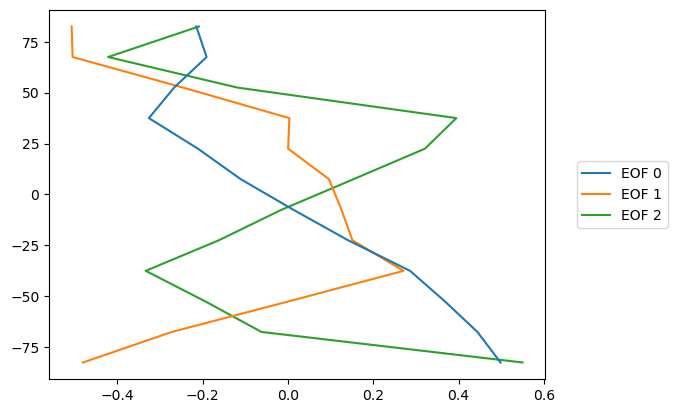

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

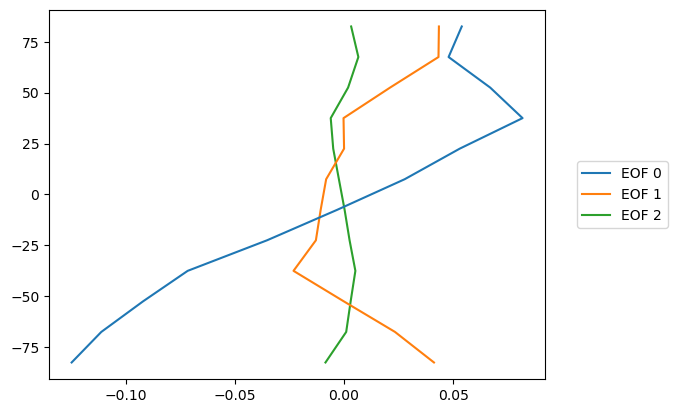

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.49817837121443137] [0.4439559631237644] [0.3677264250587059] [0.2859773788933543] [0.1408895724595264] [0.012335802677556991] [-0.11087432008033] [-0.2114453112261843] [-0.3263483169672904] [-0.26717926788891116] [-0.19110850213457597] [-0.21517645183039397]]
Units,ppt
Magnitude,[[-0.2393103457115346] [-0.2505029931325263] [-0.26217113561052124] [-0.28595174547253743] [-0.3406139576291789] [-0.3804634096300718] [-0.3489906554602547] [-0.4810389544636399] [-0.5880498816092214] [-0.47404218592176495] [-0.5092127138086766] [-0.5853381148494813] [-0.4824925561876407] [-0.6408846696007465] [-0.46985688672085607] [-0.4409736382018165]]
Units,dimensionless


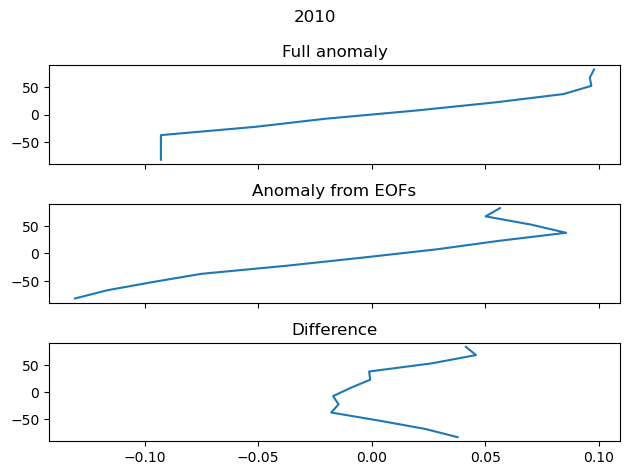

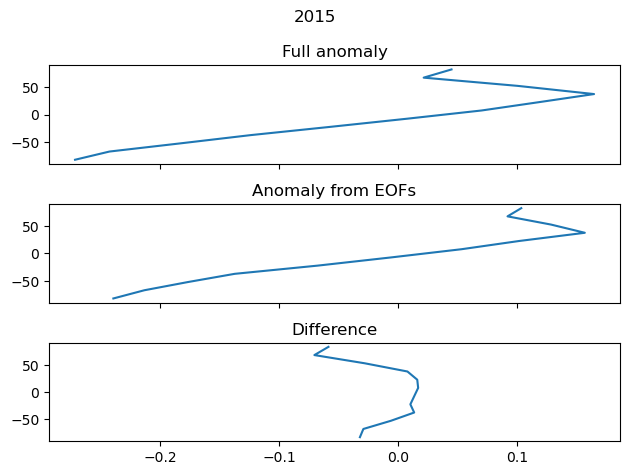

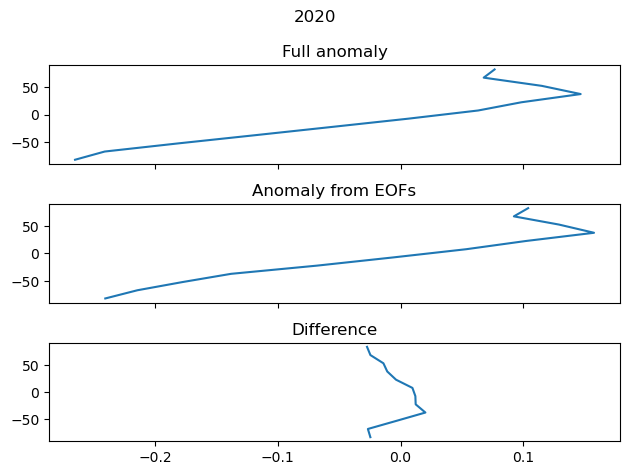

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 10427.92it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19553.86it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 17591.94it/s]

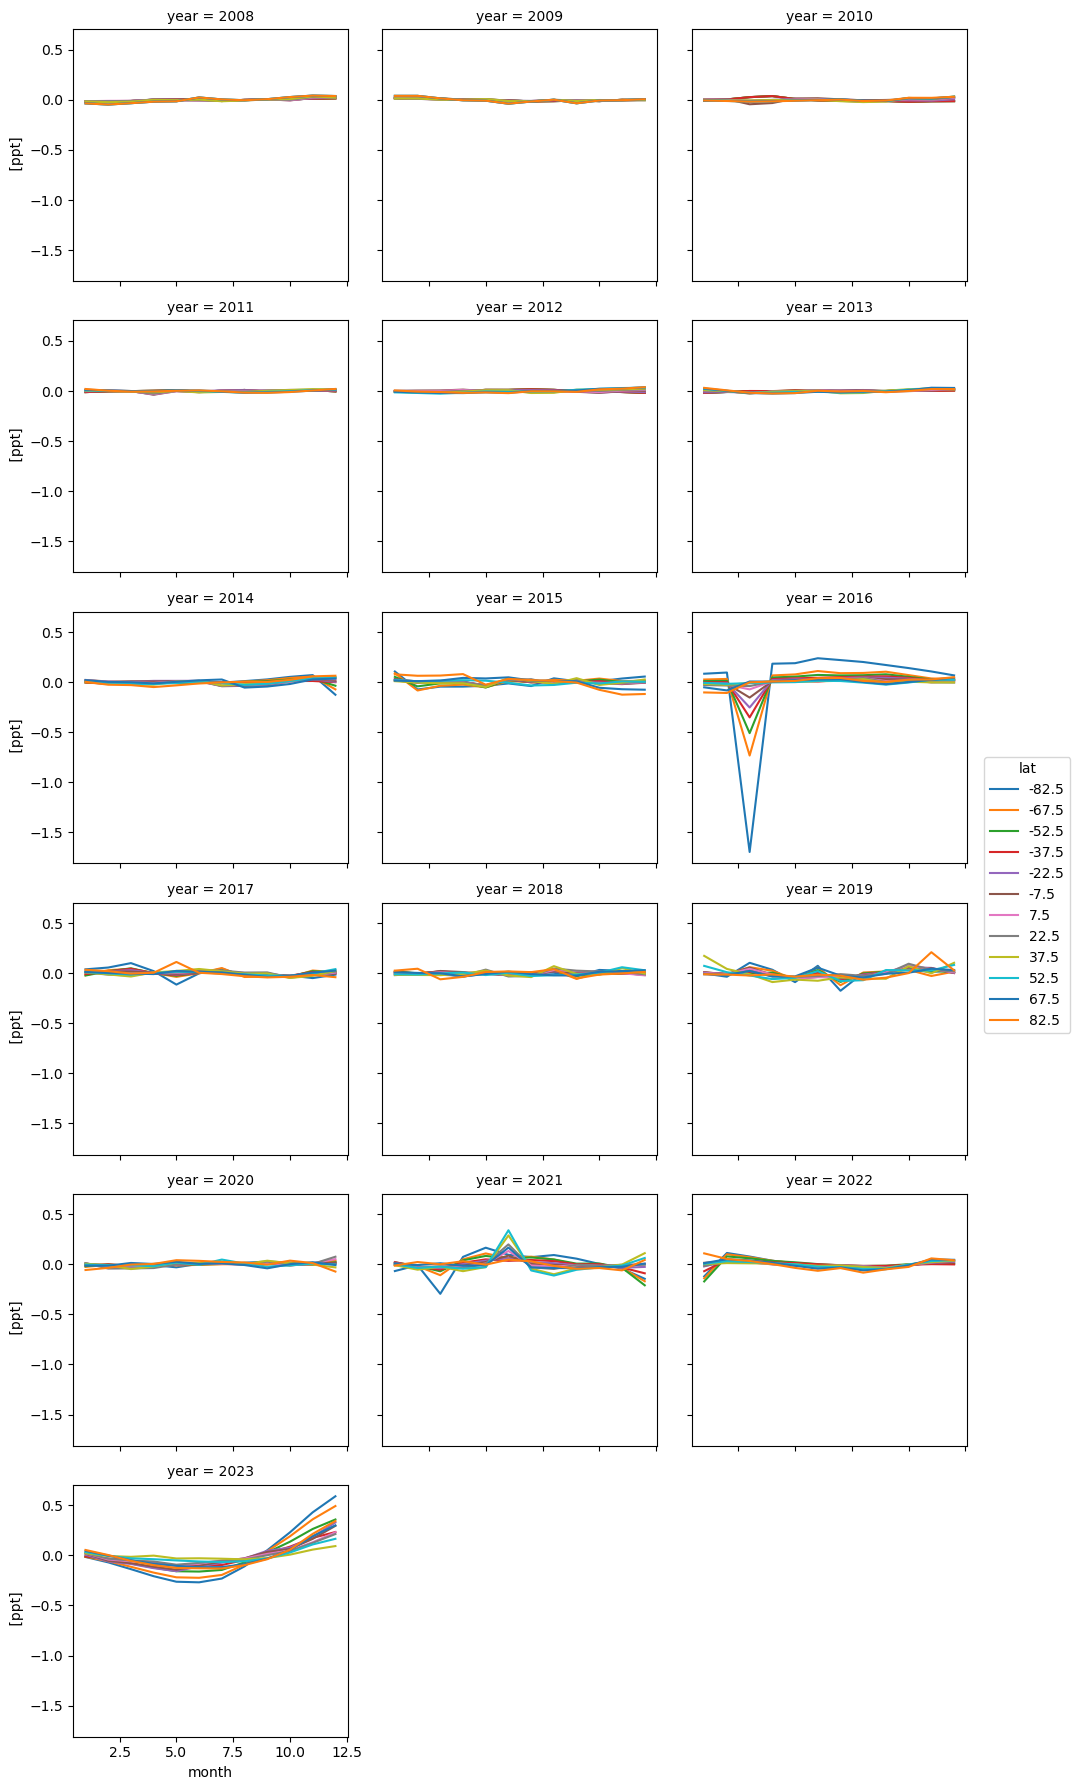

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

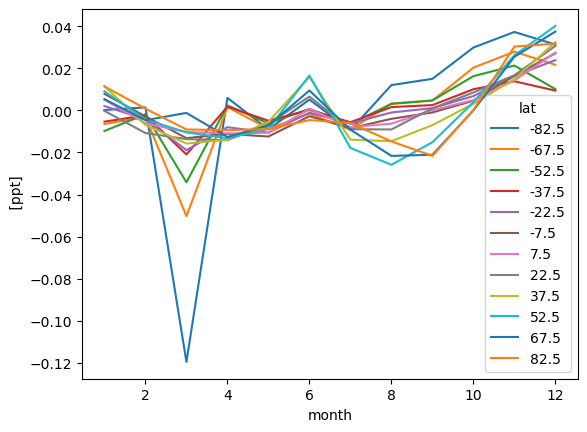

In [22]:
seasonality.plot.line(hue="lat")

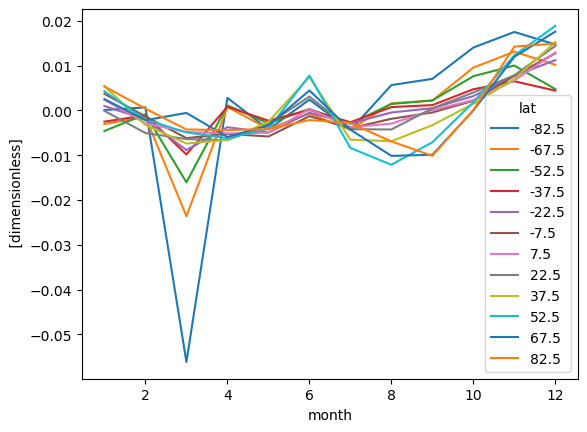

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[1.5213910325121496 1.5725721853083747 1.638314231940573 1.717993000918648 1.8040469724161372 1.9043651773576808 2.014320376194439 2.060330770117794 2.0951642325460895 2.242851047998094 2.3266966096255146 2.404645388034074 2.4509080619905217 2.56608493443307 2.8161109372991953 2.90617050219864]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.49817837121443137] [0.4439559631237644] [0.3677264250587059] [0.2859773788933543] [0.1408895724595264] [0.012335802677556991] [-0.11087432008033] [-0.2114453112261843] [-0.3263483169672904] [-0.26717926788891116] [-0.19110850213457597] [-0.21517645183039397]]
Units,ppt
Magnitude,[[-0.2393103457115346] [-0.2505029931325263] [-0.26217113561052124] [-0.28595174547253743] [-0.3406139576291789] [-0.3804634096300718] [-0.3489906554602547] [-0.4810389544636399] [-0.5880498816092214] [-0.47404218592176495] [-0.5092127138086766] [-0.5853381148494813] [-0.4824925561876407] [-0.6408846696007465] [-0.46985688672085607] [-0.4409736382018165]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[7.684897958692542e-05 0.0006635371552155567 -0.056169110287641745 0.0027883362157232064 -0.0042577394792995635 0.002402300873446372 -0.004413552887603038 0.005641222072414548 0.007034829325878837 0.014025059461895735 0.017505442815634382 0.014703319702521348] [-0.003044061794623473 -0.0014689600957182814 -0.023621477503363242 0.0007453061741121793 -0.00411559970930621 -0.0007514753103052968 -0.0042872370173938894 0.001551476054179192 0.002176508431735232 0.009545762322633577 0.013100555669765625 0.010169611367051074] [-0.004608930427237208 -0.000877730438192793 -0.016068914651385418 0.001101480485336445 -0.0029179357844063497 0.0003314371020385395 -0.0029924871168585266 0.0014328627075708023 0.002217493732494607 0.007628796094731727 0.01000193365535388 0.004752285439597593] [-0.0025199225979179824 -0.0011137288594558492 -0.009841144971364568 0.0008241769406234422 -0.0023118739181800852 9.137114006959929e-05 -0.0026509216427092076 0.0007291698849340641 0.0011766860144682067 0.004713698867118269 0.006492858837235827 0.004409810529958111] [0.0009717782546261863 -0.002049173215933082 -0.008875258622515127 -0.0037575344430033327 -0.004962006492079458 -0.0005144709458589639 -0.002915751036507185 -0.00047611596556654365 0.000493388624034343 0.0031846802210324437 0.007687121950766188 0.01121357137506824] [0.0036859746932210924 -0.001356192108278237 -0.006204931093523395 -0.005236823266667493 -0.0058433221923393334 -0.0013067916248306877 -0.003994309855252717 -0.0018864065384289438 -0.00047093015198748 0.002146280055884626 0.0077204436709468385 0.012747210195605683] [0.002373496831794867 -0.0028979448214420073 -0.00482944088205958 -0.005146197042955202 -0.0050065609882170865 0.0003100954104278526 -0.0037557043369644437 -0.002968717815145243 3.8711069426034e-05 0.0022966216081270374 0.006676679816884208 0.012909107456520031] [-0.0001074234835752593 -0.005060061075806352 -0.006420542122124785 -0.006658761576051466 -0.0030253990526839716 0.0030882284411701765 -0.004212721007217041 -0.004266676488506252 0.00045394070719810027 0.00398728369668818 0.007840266837567946 0.014381997617906673] [0.005401908604993587 -0.003257580668325197 -0.00740875488812884 -0.006572181344293068 -0.002550687227917473 0.007451539594061676 -0.006542931177337176 -0.006896478879229616 -0.003308142681909436 0.0014783578529596495 0.006995351024895163 0.015209636642065056] [0.004252497631365692 -0.0020441544164979315 -0.004916425772771542 -0.006220151688566018 -0.00412734597816674 0.0077856358050597835 -0.008394916708469606 -0.012143987797480065 -0.007120488009677775 0.0017974792141008896 0.012277870859831114 0.018854076674563864] [0.0025055049264258336 -0.002195901530423801 -0.0005713530643216682 -0.0059384950841208355 -0.003396344623099562 0.004442706618074456 -0.004296965001227641 -0.010165000314559995 -0.009911606962651361 -1.8202135237882802e-05 0.011961205286454692 0.017584651465029754] [0.005336317628052207 0.000382565167651479 -0.004265934853591509 -0.004414721528015592 -0.004181863739021629 -0.002162349779301813 -0.002839313699585081 -0.006924867012718466 -0.010159220972543626 9.844862243031443e-05 0.014241425670885268 0.01488974524447285]]
Units,dimensionless
